In [1]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"

!pip install tensorflow-model-optimization
print("Packages Installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 16.1 MB/s eta 0:00:00
Packages Installed


In [2]:
import os
import math
import zipfile
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python executable:", os.sys.executable)
print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)

Python executable: /usr/bin/python3
TensorFlow version: 2.20.0
TF-MOT version: 0.8.1


In [3]:
from google.colab import drive
import zipfile
import os
import shutil # Import shutil for directory operations

mount_point = '/content/drive'

# --- Robust Mounting Logic ---
if os.path.exists(mount_point):
    if os.path.isdir(mount_point):
        # Check if the directory is not empty and is NOT currently a mounted filesystem
        # (i.e., it might contain leftover files that are not part of an active mount)
        if os.listdir(mount_point) and not os.path.ismount(mount_point):
            print(f"Mount point '{mount_point}' exists and is not empty. Clearing contents before mounting...")
            for item in os.listdir(mount_point):
                item_path = os.path.join(mount_point, item)
                try:
                    if os.path.isfile(item_path) or os.path.islink(item_path):
                        os.remove(item_path)
                    elif os.path.isdir(item_path):
                        shutil.rmtree(item_path)
                except Exception as e:
                    print(f"Warning: Could not fully clean {item_path}: {e}")
            print(f"Contents of '{mount_point}' cleared.")
        elif os.path.ismount(mount_point):
            print("Google Drive is already mounted and appears clean. Proceeding with remount (if needed).")
        else: # Directory exists and is empty
            print(f"Mount point '{mount_point}' exists and is empty. Proceeding.")
    else: # /content/drive exists but is not a directory (e.g., a file or broken symlink)
        print(f"Warning: '{mount_point}' exists but is not a directory. Removing and recreating it.")
        os.remove(mount_point) # Remove the non-directory item
        os.makedirs(mount_point)
else: # /content/drive does not exist
    os.makedirs(mount_point)
    print(f"Mount point '{mount_point}' created.")

print("Attempting to mount Google Drive...")
# force_remount=True will handle cases where it was previously mounted by Colab
# and will re-attempt to mount even if the directory was empty before.
drive.mount(mount_point, force_remount=True)
# --- End of Robust Mounting Logic ---

Mount point '/content/drive' created.
Attempting to mount Google Drive...
Mounted at /content/drive


In [4]:
zip_path = '/content/drive/MyDrive/KaggleGazeCapture/eye_gaze_train_lsr.zip'
extract_path = '/content/eye_gaze_train_lsr/'

# Check if the extract_path does not exist or is empty
if not os.path.exists(extract_path) or not os.listdir(extract_path):
    print(f"Dataset not found locally or is empty. Extracting from Drive...")
    os.makedirs(extract_path, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction complete!")
    # Verification after extraction
    if os.path.exists(extract_path) and os.listdir(extract_path):
        print(f"Verification: '{extract_path}' exists and contains {len(os.listdir(extract_path))} items.")
    else:
        print(f"Verification: Extraction seems to have failed. '{extract_path}' is either missing or empty.")
else:
    print("Dataset directory already exists and contains data.")
    # Verification if directory already exists and contains data
    if os.path.exists(extract_path) and os.listdir(extract_path):
        print(f"Verification: '{extract_path}' already exists and contains {len(os.listdir(extract_path))} items.")
    else:
        print(f"Verification: '{extract_path}' exists but is empty. This condition should not be reached with the updated logic, but checking just in case.")

Dataset not found locally or is empty. Extracting from Drive...
Extraction complete!
Verification: '/content/eye_gaze_train_lsr/' exists and contains 2 items.


In [5]:
test_dir = extract_path + '/eye_gaze_train_lsr/test/'


test_dataset_64 = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    shuffle=True,
    image_size=(64, 64),
    color_mode='grayscale',
    interpolation='lanczos3',
    batch_size=None # Load unbatched images initially
)


class_names = test_dataset_64.class_names


test_dataset_48 = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    shuffle=True,
    image_size=(48, 48),
    color_mode='grayscale',
    interpolation='lanczos3',
    batch_size=None # Load unbatched images initially
)

Found 32233 files belonging to 3 classes.
Found 32233 files belonging to 3 classes.


In [6]:
def normalize_images(image, label):
    # This function now receives a single image (3-D tensor: H, W, C)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

AUTOTUNE = tf.data.AUTOTUNE # Keep AUTOTUNE defined here

In [7]:
BATCH_SIZE = 32

test_ds_64 = test_dataset_64.map(normalize_images, num_parallel_calls=AUTOTUNE) # Renamed for consistency
test_ds_64 = test_ds_64.batch(BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)


test_ds_48 = test_dataset_48.map(normalize_images, num_parallel_calls=AUTOTUNE) # Renamed for consistency
test_ds_48 = test_ds_48.batch(BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)

In [8]:
import numpy as np

# Extract all images and labels from the test_dataset
all_test_images_64 = []
all_test_labels_64 = []

for images, labels in test_ds_64:
    all_test_images_64.append(images.numpy())
    all_test_labels_64.append(labels.numpy())

X_test_64 = np.vstack(all_test_images_64)
y_test_64 = np.concatenate(all_test_labels_64)



all_test_images_48 = []
all_test_labels_48 = []

for images, labels in test_ds_48:
    all_test_images_48.append(images.numpy())
    all_test_labels_48.append(labels.numpy())

X_test_48 = np.vstack(all_test_images_48)
y_test_48 = np.concatenate(all_test_labels_48)

print(f"Shape of X_test_64: {X_test_64.shape}")
print(f"Shape of y_test_64: {y_test_64.shape}")

print(f"Shape of X_test_48: {X_test_48.shape}")
print(f"Shape of y_test_48: {y_test_48.shape}")

Shape of X_test_64: (32233, 64, 64, 1)
Shape of y_test_64: (32233,)
Shape of X_test_48: (32233, 48, 48, 1)
Shape of y_test_48: (32233,)


In [9]:
MODEL_DIR = '/content/drive/MyDrive/saved_models'

tfx_model_name_64 = 'transfer_eye_gaze_lsr_mobilenetv2_64px_alpha005_ptq.tflite'
model_name_64 = 'eye_gaze_lsr_mobilenetv2_64px_alpha005_ptq.tflite'
model_name_48 = 'eye_gaze_lsr_mobilenetv2_48px_alpha005_ptq.tflite'

tfx_model_path_64 = os.path.join(MODEL_DIR, tfx_model_name_64)
model_path_64 = os.path.join(MODEL_DIR, model_name_64)
model_path_48 = os.path.join(MODEL_DIR, model_name_48)

In [10]:
def evaluate_tflite_model(model_path, X_test, y_test):
    interpreter = tf.lite.Interpreter(model_path=model_path)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X_test)):
        x = X_test[i:i+1].astype(np.float32)

        if input_details["dtype"] == np.int8:
            x = np.round(x / input_scale + input_zero_point).astype(np.int8)
        elif input_details["dtype"] == np.uint8:
            x = np.round(x / input_scale + input_zero_point).astype(np.uint8)
        else:
            x = x.astype(input_details["dtype"])


        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        if output_details["dtype"] in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)

    test_acc = accuracy_score(y_test, y_pred)

    print(f"Test Accuracy: {test_acc:.4f}\n")
    print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_test, y_pred),
        display_labels=class_names
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
    plt.title(f"TFLite Model Confusion Matrix")
    plt.show()

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Test Accuracy: 0.6970

              precision    recall  f1-score   support

        left     0.7909    0.6223    0.6966      8923
       right     0.7090    0.7217    0.7153      9529
    straight     0.6471    0.7284    0.6854     13781

    accuracy                         0.6970     32233
   macro avg     0.7157    0.6908    0.6991     32233
weighted avg     0.7052    0.6970    0.6973     32233



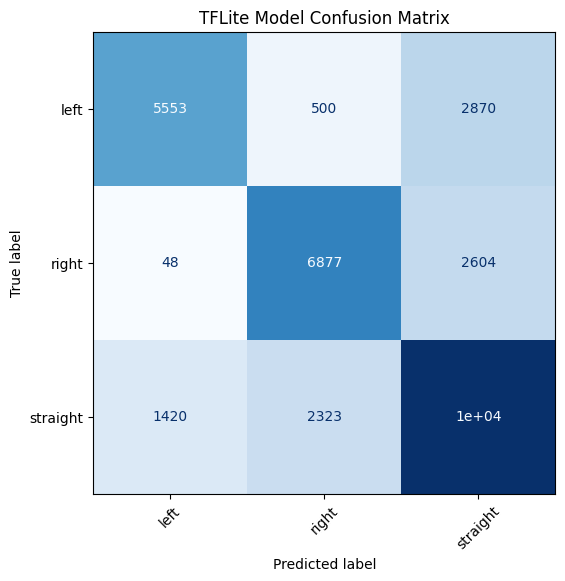

In [11]:
evaluate_tflite_model(model_path_64, X_test_64, y_test_64)

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Test Accuracy: 0.6912

              precision    recall  f1-score   support

        left     0.7062    0.7189    0.7125      8923
       right     0.7032    0.7304    0.7165      9529
    straight     0.6719    0.6460    0.6587     13781

    accuracy                         0.6912     32233
   macro avg     0.6937    0.6985    0.6959     32233
weighted avg     0.6906    0.6912    0.6907     32233



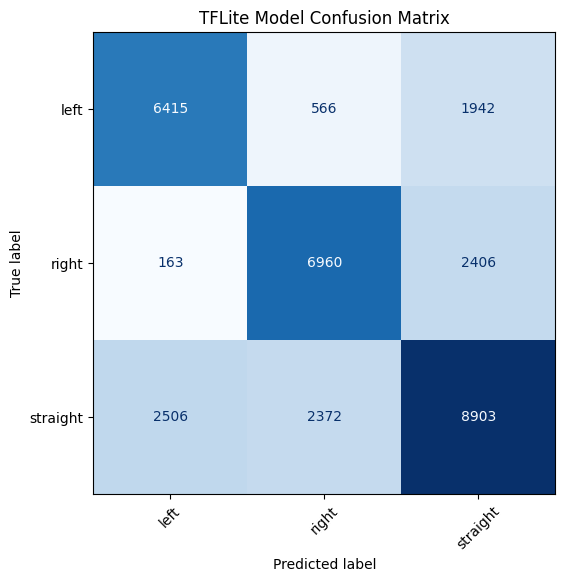

In [12]:
evaluate_tflite_model(model_path_48, X_test_48, y_test_48)

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Test Accuracy: 0.3828

              precision    recall  f1-score   support

        left     0.3495    0.4623    0.3980      8923
       right     0.3487    0.5484    0.4263      9529
    straight     0.5492    0.2169    0.3110     13781

    accuracy                         0.3828     32233
   macro avg     0.4158    0.4092    0.3784     32233
weighted avg     0.4347    0.3828    0.3692     32233



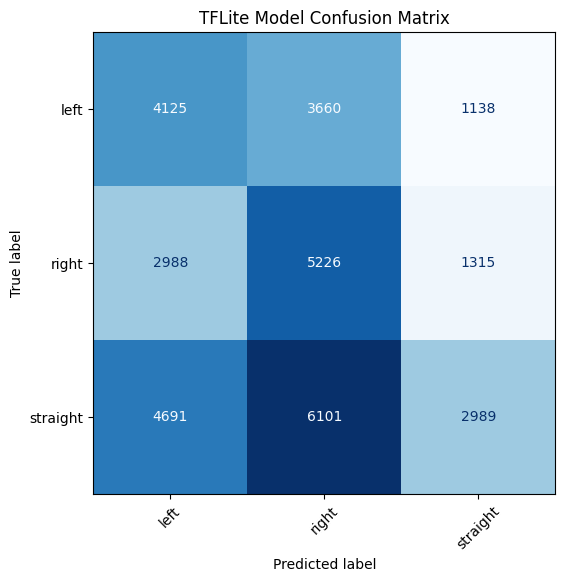

In [13]:
evaluate_tflite_model(tfx_model_path_64, X_test_64, y_test_64)